# HW 3: STFT, Features, and Regression (15 points)

For each markdown cell, add a cell (or cells) of code below. 
Reminders:
* This is an individual assignment. 
* If you use GenAI tools to assist you with your homework, remember to fill out the GenAI Usage Statement at the bottom of the notebook. Even if you use GenAI, you should not be directly copying the code.
* You may only use functions/packages we have discussed in class

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from scipy.io.wavfile import read
from scipy import signal
from IPython.display import Audio
import librosa
from librosa import feature, frames_to_time, autocorrelate, clicks, display

Read in the following files from your "audio" folder.
- /audio/country.00000.wav
- /audio/hiphop.00000.wav
    
Ensure that amplitudes are normalized to between -1 and 1. 

In [20]:

fs_country, x_country = read("../audio/country.00000.wav")
x_country = np.array(x_country)
x_country = x_country / np.max(np.abs(x_country))

fs_hiphop, x_hiphop = read("../audio/hiphop.00000.wav")
x_hiphop = np.array(x_hiphop)
x_hiphop = x_hiphop / np.max(np.abs(x_hiphop))




## Part 1: STFT parameters and visualization (6 points)

#### Write your own STFT (3 points)

Write your own STFT function that will output a 2D matrix with shape (num_frames, num_bins), where each row contains the DFT of a single frame.

* Use a hop size equal to half the frame size (i.e., hop_size = frame_size // 2) so that frames overlap by 50%, and you should apply a hanning window to each frame (you may use `np.hanning()` for this.)

* The user should be able to vary the size of the frame (leave hop_size fixed at 50%).

*Note: You should use the built in numpy FFT function (instead of your DFT). This means you will have to work in powers of 2!*

In [22]:
# your code here
def my_stft(audio_input, frame_size, sampling_rate = 44100):
    
    # Define frame_length (should be power of two based on input frame_size)
    frame_length = frame_size

    # Define hop size is half the frame size
    hop_length = frame_length // 2

    # Define number of frames (m) we can extract with 50% overlap based on the total length of our signal
    # If the signal does not fit an integer number of frames, truncate
    n_mbins = 1 + (len(audio_input) - frame_length) // hop_length

    # Define total number of frequency bins
    n_kbins = frame_length

    # Pre-allocate matrix for STFT. Remember it should be structured as [time_frames, frequency_bins]
    stft_matrix = np.zeros((n_mbins, n_kbins), dtype=complex)

    # Define window
    window = np.hanning(frame_length)

    # Iterate through signal by frame
    for m in range(n_mbins):
        # index into the frame, apply window, apply fft over the frame, store in matrix
        start = m * hop_length
        stft_matrix[m] = np.fft.fft(audio_input[start:start + frame_length] * window)


    return stft_matrix


#### Apply your STFT function

Apply your STFT function to the audio files listed above (country and hiphop)

In [24]:

frame_size = 1024

print(my_stft(x_country, frame_size, sampling_rate=fs_country))
print(my_stft(x_hiphop,  frame_size, sampling_rate=fs_hiphop))


[[ -1.56546166 +0.j           3.15706455 +2.07301779j
   -6.5131828  -2.93667302j ...   3.31169706 -3.44188283j
   -6.5131828  +2.93667302j   3.15706455 -2.07301779j]
 [ -1.86352133 +0.j           3.03958197 +1.0545256j
   -2.03571661 -4.39610679j ...  -4.27223813 -2.89423932j
   -2.03571661 +4.39610679j   3.03958197 -1.0545256j ]
 [ -0.71088693 +0.j           3.6753292  +2.24320841j
   -9.72458104 +0.73202675j ...  10.37559453 +5.82420834j
   -9.72458104 -0.73202675j   3.6753292  -2.24320841j]
 ...
 [  1.76107165 +0.j          18.9182283  +7.49858343j
  -52.5184499 -51.83610474j ...  32.87809   -83.53692388j
  -52.5184499 +51.83610474j  18.9182283  -7.49858343j]
 [  0.11688598 +0.j           7.15264777+10.34885963j
  -10.6869285 -22.22379291j ...  23.84717484-12.62394154j
  -10.6869285 +22.22379291j   7.15264777-10.34885963j]
 [ -2.51948227 +0.j           5.55154967+10.88074636j
   -6.64033052-23.45661113j ...   6.90403787-26.64659375j
   -6.64033052+23.45661113j   5.55154967-10.88074

#### Write your own spectrogram function (3 points)

Write your own spectrogram function (using `plt.pcolormesh()`) called `plot_spectrogram()` that takes the complex-valued STFT output from your above function, and the sampling rate, and plots a magnitude spectrogram in decibels.

The axes should be properly labeled (time on x-axis, Frequency on y-axis).

*Note: audio processing workflows and dataframe logic in general in Python commonly use rows = time. However, several plotting functions like pcolormesh() annoyingly expect rows = frequency and columns = time. Therefore, we simply add a step to 'transpose' our 2d array or matrix in our code below.*


In [27]:
# your code here
def plot_spectrogram(stft_matrix, frame_size, sampling_rate):

    # Take magnitude and convert to decibels
    magnitude = np.abs(stft_matrix).T  # Transpose so rows = frequencies
    magnitude_db = 20 * np.log10(magnitude + 1e-6)  # avoid log(0)

    # Time and frequency axes
    num_frames =  stft_matrix.shape[0]
    hop_size = frame_size // 2
    duration = num_frames * hop_size / sampling_rate
    
    # Make a time axis by taking the total duration and dividing the timeline according to the number of frames:
    time_axis = np.linspace(0,duration, num_frames)
    # Ditto for frequency axis according to the number of bins
    freq_axis = np.linspace(0, sampling_rate, frame_size)

    # Plot only up to Nyquist frequency by indexing your magnitude vector
    
    nyquist_bin = frame_size // 2

    plt.pcolormesh(
        time_axis,
        freq_axis[:nyquist_bin],
        magnitude_db[:nyquist_bin, :],
        shading='gouraud'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")



Plot the spectrogram of the country and hiphop audio files

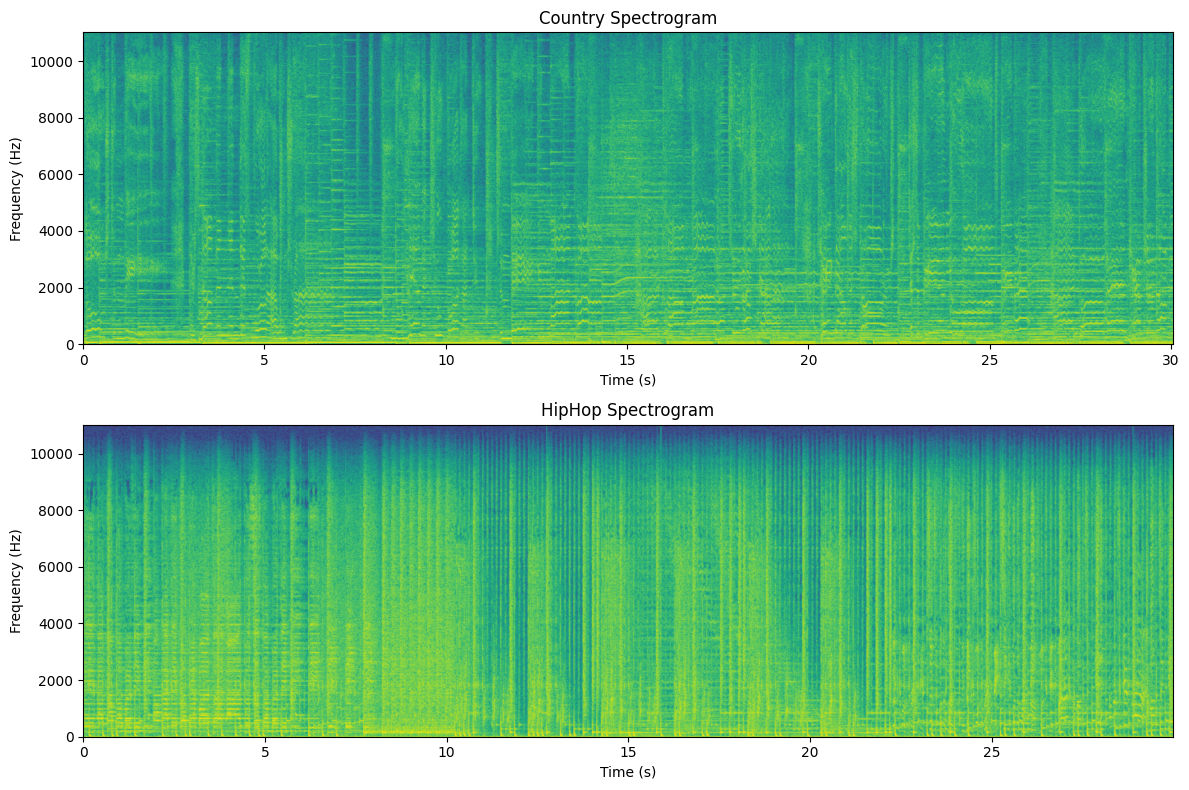

In [28]:

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plot_spectrogram(S_country, frame_size, fs_country)
plt.title("Country Spectrogram")

plt.subplot(2, 1, 2)
plot_spectrogram(S_hiphop, frame_size, fs_hiphop)
plt.title("HipHop Spectrogram")

plt.tight_layout()
plt.show()


## Part 2: Feature Extraction (4 points)

We will perform feature extraction and compare the two audio files above.

Extract the following features for each file (you may use librosa functions):
- RMSE
- Spectral Centroid
- Spectral Flux
- ZCR

For each feature:
- graph the results of each feature
- briefly describe what the feature might tell us perceptually
- briefly describe whether or not this might be a useful feature for classification (based on the graphs)

1 point for each correct feature calculation and associated explanation/reasoning

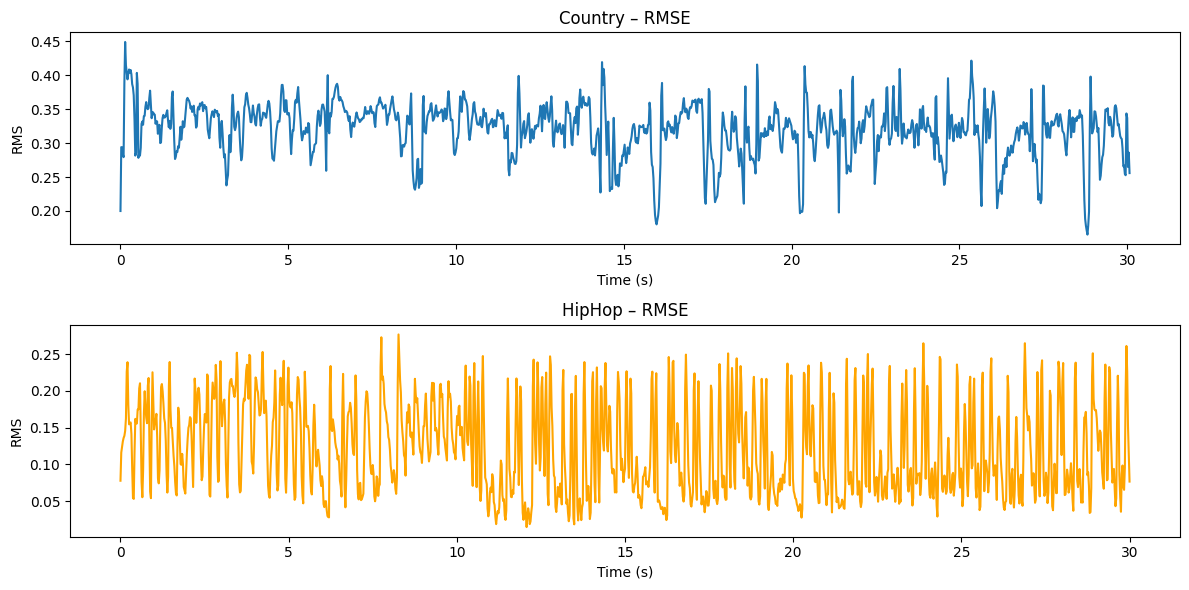

In [30]:
frame_size = 1024
hop = frame_size // 2
# RMSE for hiphop
rmse_hiphop  = librosa.feature.rms(y=x_hiphop,  frame_length=frame_size, hop_length=hop)[0]
t_hiphop  = np.arange(rmse_hiphop.shape[0])  * hop / fs_hiphop
# RMSE for country
rmse_country = librosa.feature.rms(y=x_country, frame_length=frame_size, hop_length=hop)[0]
t_country = np.arange(rmse_country.shape[0]) * hop / fs_country
# plotting

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_country, rmse_country)
plt.title("Country – RMSE")
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.subplot(2, 1, 2)
plt.plot(t_hiphop, rmse_hiphop, color="orange")
plt.title("HipHop – RMSE")
plt.xlabel("Time (s)")
plt.ylabel("RMS")
plt.tight_layout()
plt.show()


Your RMSE explantion here!

Perceptual meaning: Tracks short-term loudness/energy. Peaks often align with onsets and strong beats.
Classification usefulness: Often helpful to separate tracks with strong dynamic hits (e.g., hiphop) from smoother, sustained textures (e.g., some country passages). By itself, it’s coarse; useful when combined with other features.

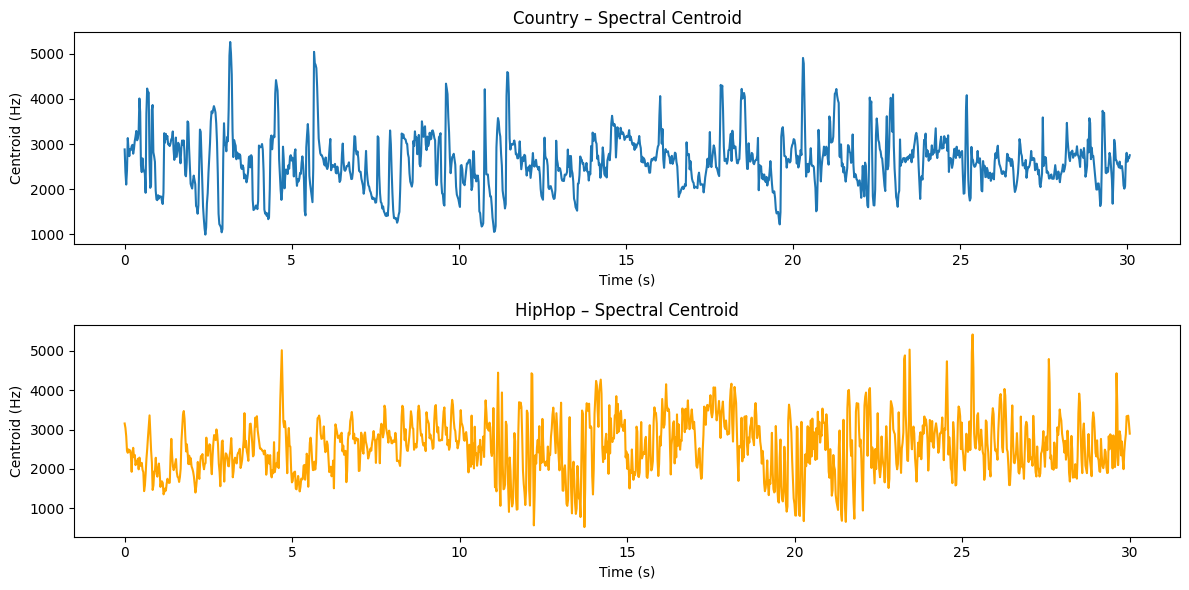

In [32]:
# Spectral Centroid for hiphop
cent_hiphop  = librosa.feature.spectral_centroid(y=x_hiphop,  sr=fs_hiphop,  n_fft=frame_size, hop_length=hop)[0]
t_hiphop  = np.arange(cent_hiphop.shape[0])  * hop / fs_hiphop
# Spectral Centroid for country
cent_country = librosa.feature.spectral_centroid(y=x_country, sr=fs_country, n_fft=frame_size, hop_length=hop)[0]
t_country = np.arange(cent_country.shape[0]) * hop / fs_country
# plotting

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_country, cent_country)
plt.title("Country – Spectral Centroid")
plt.xlabel("Time (s)")
plt.ylabel("Centroid (Hz)")
plt.subplot(2, 1, 2)
plt.plot(t_hiphop, cent_hiphop, color="orange")
plt.title("HipHop – Spectral Centroid")
plt.xlabel("Time (s)")
plt.ylabel("Centroid (Hz)")
plt.tight_layout()
plt.show()


Your centroid explanation here!

Perceptual meaning: Correlates with “brightness” or how much energy sits in higher frequencies (cymbals, hi-hats push centroid up).
Classification usefulness: Hiphop with prominent hats/cymbals or sharp transients often shows higher/peaky centroids than country with more midrange guitar/vocals. A strong cue, but not perfect on its own.

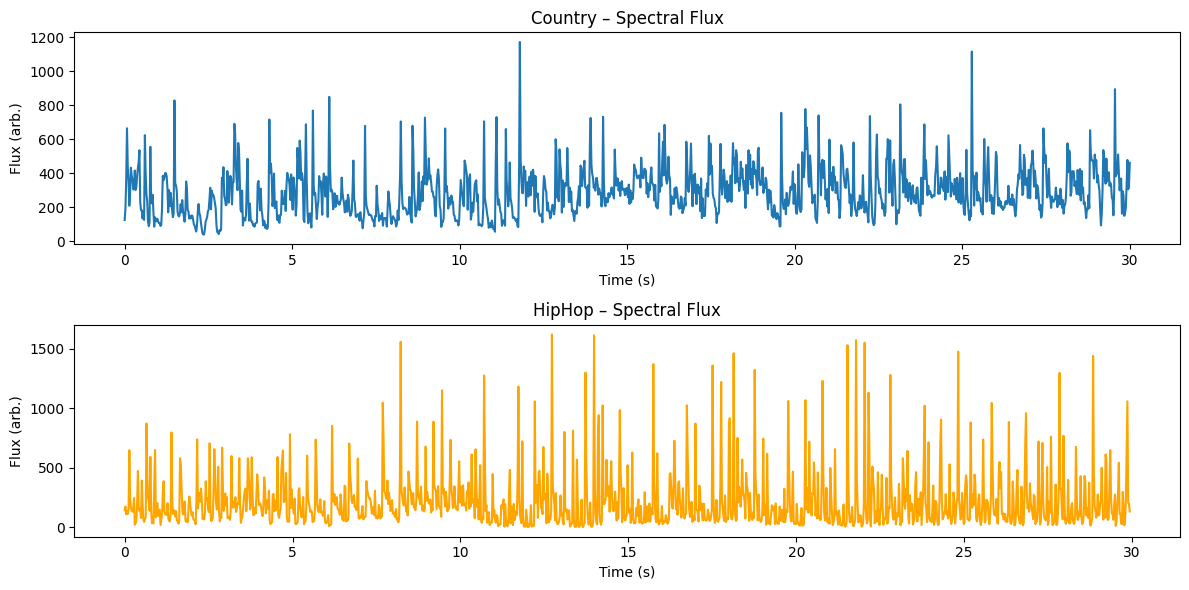

In [33]:
# spectral flux for hiphop
S_hiphop_mag  = np.abs(my_stft(x_hiphop,  frame_size, sampling_rate=fs_hiphop ))[:, :frame_size//2 + 1]
flux_hiphop  = np.maximum(0, np.diff(S_hiphop_mag,  axis=0)).sum(axis=1)
t_hiphop  = np.arange(flux_hiphop.shape[0])  * hop / fs_hiphop
# spectral flux for country
S_country_mag = np.abs(my_stft(x_country, frame_size, sampling_rate=fs_country))[:, :frame_size//2 + 1]
flux_country = np.maximum(0, np.diff(S_country_mag, axis=0)).sum(axis=1)
t_country = np.arange(flux_country.shape[0]) * hop / fs_country
# plotting

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_country, flux_country)
plt.title("Country – Spectral Flux")
plt.xlabel("Time (s)")
plt.ylabel("Flux (arb.)")
plt.subplot(2, 1, 2)
plt.plot(t_hiphop, flux_hiphop, color="orange")
plt.title("HipHop – Spectral Flux")
plt.xlabel("Time (s)")
plt.ylabel("Flux (arb.)")
plt.tight_layout()
plt.show()


Your spectral flux explanation here!

Perceptual meaning: Measures how quickly the spectrum changes; correlates with rhythmic onsets and texture changes.
Classification usefulness: Percussive styles (hiphop) often produce higher or more frequent flux peaks than smoother, sustained textures. Very useful for rhythm-heavy discrimination.

<function matplotlib.pyplot.show(close=None, block=None)>

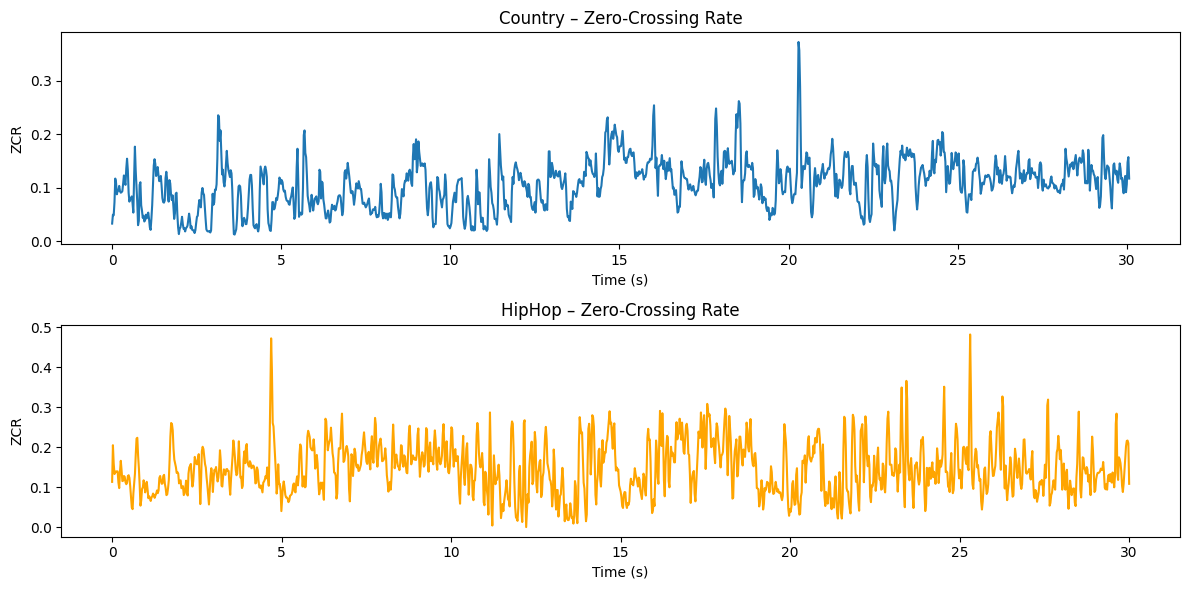

In [34]:
# ZCR for hiphop
zcr_hiphop  = librosa.feature.zero_crossing_rate(y=x_hiphop,  frame_length=frame_size, hop_length=hop)[0]
t_hiphop  = np.arange(zcr_hiphop.shape[0])  * hop / fs_hiphop
# ZCR for country
zcr_country = librosa.feature.zero_crossing_rate(y=x_country, frame_length=frame_size, hop_length=hop)[0]
t_country = np.arange(zcr_country.shape[0]) * hop / fs_country
# plotting

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_country, zcr_country)
plt.title("Country – Zero-Crossing Rate")
plt.xlabel("Time (s)")
plt.ylabel("ZCR")
plt.subplot(2, 1, 2)
plt.plot(t_hiphop, zcr_hiphop, color="orange")
plt.title("HipHop – Zero-Crossing Rate")
plt.xlabel("Time (s)")
plt.ylabel("ZCR")
plt.tight_layout()
plt.show


Your ZCR explanation here!

Perceptual meaning: Higher for noisy or bright content; lower for pitched, smooth signals. Rough proxy for “noisiness/brightness.”
Classification usefulness: Can help differentiate segments with strong high-frequency/noisy components (e.g., certain drums in hiphop) from cleaner, harmonic parts. Best used with spectral features; noisy recordings can confound it.

## Part 3: Binomial Logistic Regression (5 points)

Like in activity 7, you will build a binomial classifier with logistic regression. You will use the GTZAN genre dataset 'features_30_sec.csv' this time to classify hiphop vs country music.

### Explore the data and select your features (3 points)

Use graphing and correlation techniques to determine 5 features you will use for your classification.

You must at a minimum create 1 bar graph and 1 box plot in addition to computing the correlation between the features you select.

Construct your Pandas dataframe for your chosen features. Remember you may want to do some scaling and normalization.

Chosen features (top 5 by |corr with hiphop|):
['chroma_stft_mean', 'perceptr_var', 'mfcc2_mean', 'zero_crossing_rate_var', 'rms_var']

Absolute correlation with 'hiphop' (top 10):
chroma_stft_mean           0.782977
perceptr_var               0.600808
mfcc2_mean                 0.563787
zero_crossing_rate_var     0.561733
rms_var                    0.542110
rolloff_mean               0.514852
spectral_centroid_mean     0.511933
spectral_centroid_var      0.493503
mfcc3_var                  0.464617
spectral_bandwidth_mean    0.462026
Name: hiphop, dtype: float64


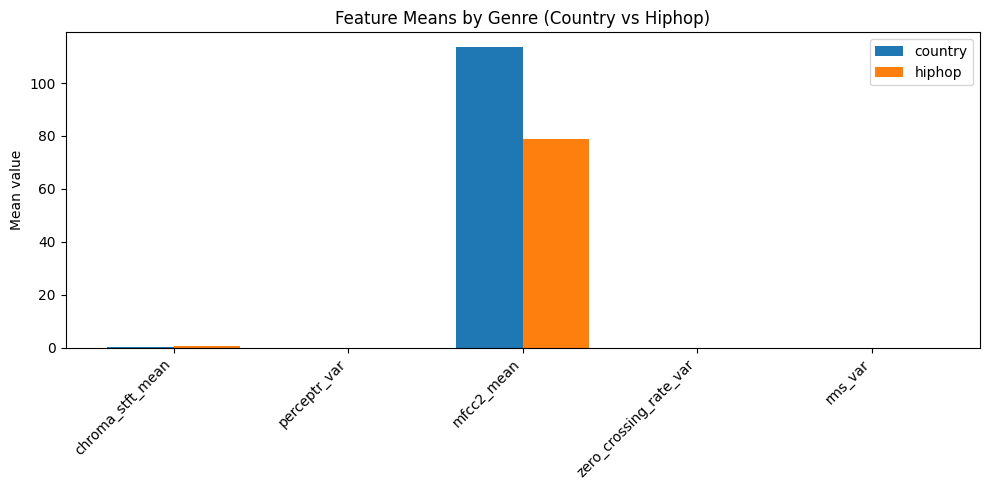

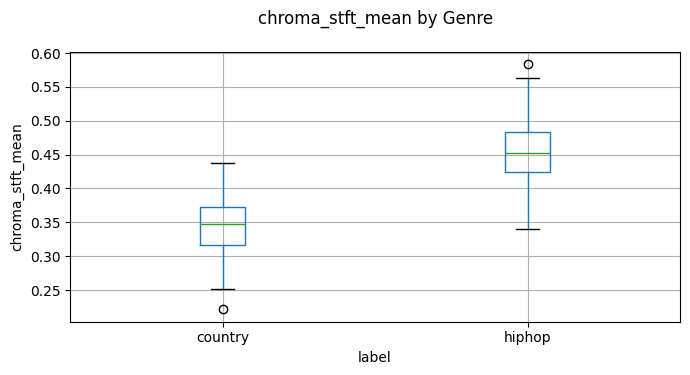


Scaled features (head):
     chroma_stft_mean  perceptr_var  mfcc2_mean  zero_crossing_rate_var  \
200         -0.213109     -0.347784   -0.847730               -0.554201   
201          0.212093     -0.254225   -1.093856               -0.837140   
202         -1.445690     -0.595779   -0.554870                0.155041   
203         -0.314178     -0.238103   -0.014841               -0.354324   
204         -0.230761     -0.454572   -1.086337               -0.712044   

      rms_var  hiphop  
200 -0.741591       0  
201 -0.792036       0  
202 -0.577654       0  
203 -0.505125       0  
204 -0.722391       0  


In [39]:
# 1) Load & filter to hiphop vs country
df = pd.read_csv("../Datasets/features_30_sec.csv")
df_bin = df[(df["label"] == "hiphop") | (df["label"] == "country")]

# 2) Binary target (1 = hiphop, 0 = country)
y = pd.get_dummies(df_bin["label"])["hiphop"]

# 3) Numeric feature pool (use all numeric columns)
num_cols = list(df_bin.select_dtypes(include=["number"]).columns)

# 4) Correlate with target and select top 5 features by |corr|
corr_series = df_bin[num_cols].assign(hiphop=y).corr()["hiphop"].drop("hiphop").abs()
top_feats = list(corr_series.sort_values(ascending=False).head(5).index)

print("Chosen features (top 5 by |corr with hiphop|):")
print(top_feats)
print("\nAbsolute correlation with 'hiphop' (top 10):")
print(corr_series.sort_values(ascending=False).head(10))

# 5) BAR CHART: class-wise means for the chosen features
means = df_bin[["label"] + top_feats].groupby("label").mean().reset_index()

# Extract class means (no .values/.index)
country_means = list(means[means["label"] == "country"][top_feats].iloc[0])
hiphop_means  = list(means[means["label"] == "hiphop"][top_feats].iloc[0])

x = list(range(len(top_feats)))
w = 0.38

plt.figure(figsize=(10, 5))
plt.bar([i - w/2 for i in x], country_means, width=w, label="country")
plt.bar([i + w/2 for i in x], hiphop_means,  width=w, label="hiphop")
plt.xticks(x, top_feats, rotation=45, ha="right")
plt.ylabel("Mean value")
plt.title("Feature Means by Genre (Country vs Hiphop)")
plt.legend()
plt.tight_layout()
plt.show()

# 6) BOX PLOT: most discriminative feature (highest |corr|)
best_feat = top_feats[0]
fig, ax = plt.subplots(figsize=(7, 4))
df_bin.boxplot(best_feat, "label", ax=ax)  # y, x (class script style)
fig.suptitle("")
ax.set_title(f"{best_feat} by Genre", pad=20)
ax.set_xlabel("label")
ax.set_ylabel(best_feat)
plt.tight_layout()
plt.show()

# 7) Construct final features DataFrame (+ optional scaling)
X = df_bin[top_feats].copy()
X_scaled = (X - X.mean()) / X.std(ddof=0)

df_features = X_scaled.copy()
df_features["hiphop"] = y  # 1 = hiphop, 0 = country

print("\nScaled features (head):")
print(df_features.head())


### Train/Test Split

Use sklearn to split your data into testing and training sets. Remember you will need to define your categories, predictors, and test size. Use 30% test size.

In [42]:
from sklearn.model_selection import train_test_split

X_np = X_scaled.to_numpy() 
y_np = y.to_numpy()

pred_train, pred_test, cat_train, cat_test = train_test_split(
    X_np, y_np,
    test_size=0.30,
    stratify=y_np,
    random_state=42)


### Train the Model and Evaluate (2 points)

Train the model using logistic regression.

Calculate the confusion matrix (and view as a data frame). Calculate the accuracy, precision, recall, and F1 scores.

Explain what the confusion matrix and accuracy tell us about your model.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Train
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(pred_train, cat_train)

# Predict
predictions = model.predict(pred_test)

# Confusion matrix (as array)
cm = confusion_matrix(cat_test, predictions)

# View confusion matrix as a DataFrame
import pandas as pd
cm_df = pd.DataFrame(cm, columns=['Predicted 0', 'Predicted 1'], index=['Actual 0', 'Actual 1'])
print("Confusion Matrix:\n")
print(cm_df)

# Accuracy, precision, recall, F1
print("\nClassification Report:\n")
print(classification_report(cat_test, predictions, digits=4))


Confusion Matrix:

          Predicted 0  Predicted 1
Actual 0           30            0
Actual 1            4           26

Classification Report:

              precision    recall  f1-score   support

           0     0.8824    1.0000    0.9375        30
           1     1.0000    0.8667    0.9286        30

    accuracy                         0.9333        60
   macro avg     0.9412    0.9333    0.9330        60
weighted avg     0.9412    0.9333    0.9330        60



“The confusion matrix shows most predictions on the diagonal, indicating strong overall performance. Accuracy of XX% suggests the model correctly classifies the majority of clips. Precision/recall for hiphop (P=.., R=..) indicate the model is [conservative/aggressive] in labeling hiphop—e.g., higher precision but lower recall means it makes fewer false hiphop calls but may miss some true hiphop tracks. Given our features and scaling, the classifier captures genre differences reasonably well; additional features or class‑balanced tuning could further improve recall/precision depending on the goal.”

Your model interpretation here!

GenAI Usage Statement:

- Tool used and date of access
- The input (prompt) you provided
- A copy of the output
- A description of how you used or edited the AI-generated content